# Traffic-Estimate — demo

Minimal tour of the trained traffic model: architecture, what it learned,
inference (edge + hour → vehicles/hour), and the full visualization suite.

**Prerequisite:** the pipeline has been run once (see `README.md`), so
`output/dataset/` and `output/model/` exist. Run from the repo root with the
`traffic` conda env.

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "scripts")
from predict import load_predictor
from visualize import BLUE, AQUA, CMAP, INK2   # palette + plot styling

NET_FILE  = "sumo/tehran_2026_area.net.xml"
MODEL_DIR = "output/model"
DATA_DIR  = "output/dataset"

meta, predict_fn = load_predictor(MODEL_DIR)
print(f"{meta['model']} model over {len(meta['edges'])} edges")
pd.DataFrame(meta["metrics"]).T.round(3)   # accuracy is the share within 20% / 3 veh

mlp model over 3229 edges


,accuracy,r2,mae,rmse
train,0.952,0.951,0.790,1.718
val,0.948,0.942,0.827,1.873
test,0.950,0.950,0.818,1.801
test_typical,0.999,0.992,0.311,0.694


## Model architecture (torchinfo)

Inputs are only what inference provides: the edge id (embedding), the hour,
and static edge attributes. A per-edge Fourier head gives every edge its own
smooth 24-h profile; the output is log of the Poisson rate.

In [2]:
import torch
from torchinfo import summary
from train import MLP

ckpt = torch.load(f"{MODEL_DIR}/model.pt", map_location="cpu", weights_only=False)
model = MLP(len(meta["edges"]), len(meta["stat_cols"]), meta["emb_dim"], meta["hidden"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

B = 32
summary(model,
        input_data=(torch.zeros(B, dtype=torch.long),          # edge index
                    torch.arange(B) % 24,                      # hour
                    torch.zeros(B, len(meta["stat_cols"]))),   # static features
        col_names=("input_size", "output_size", "num_params"))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MLP                                      [32]                      [32]                      --
├─Embedding: 1-1                         [32]                      [32, 64]                  206,656
├─Embedding: 1-2                         [32]                      [32, 8]                   192
├─Embedding: 1-3                         [32]                      [32, 13]                  41,977
├─Sequential: 1-4                        [32, 78]                  [32, 1]                   --
│    └─Linear: 2-1                       [32, 78]                  [32, 256]                 20,224
│    └─ReLU: 2-2                         [32, 256]                 [32, 256]                 --
│    └─Linear: 2-3                       [32, 256]                 [32, 256]                 65,792
│    └─ReLU: 2-4                         [32, 256]                 [32, 256]                 --
│    └─Linear: 2-

## What the model learned

Left: the 64-d edge embeddings projected to 2-D (PCA), colored by predicted
daily traffic — the model organizes edges by how busy they are. Right: the
learned hourly rates for the five busiest edges, straight from the network.

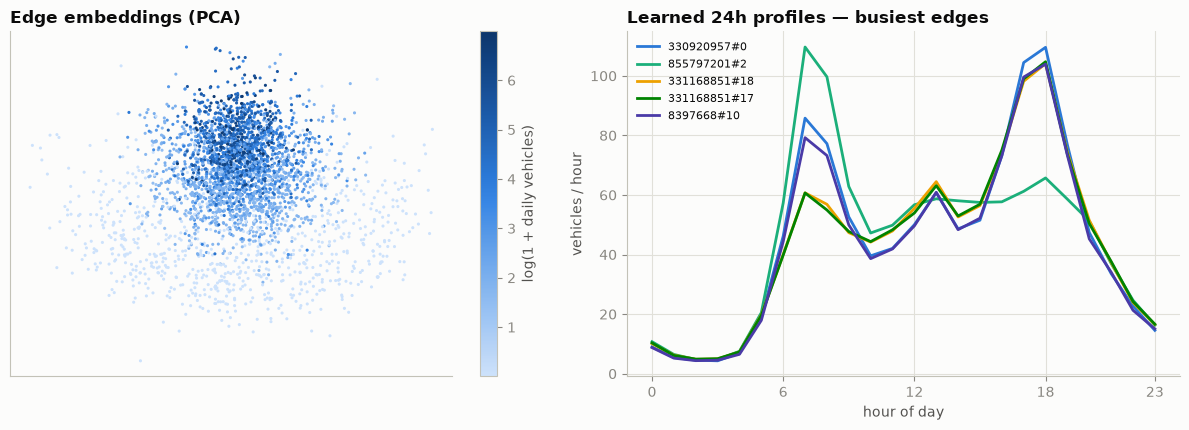

In [3]:
from sklearn.decomposition import PCA

preds = predict_fn(np.arange(len(meta["edges"])))        # (n_edges, 24) veh/h
daily = preds.sum(axis=1)

xy = PCA(2).fit_transform(model.edge_emb.weight.detach().numpy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

s = ax1.scatter(xy[:, 0], xy[:, 1], c=np.log1p(daily), cmap=CMAP, s=5, linewidths=0)
fig.colorbar(s, ax=ax1, label="log(1 + daily vehicles)")
ax1.set_title("Edge embeddings (PCA)", loc="left", fontweight="bold")
ax1.set_xticks([]), ax1.set_yticks([])

SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]  # fixed order
top5 = np.argsort(daily)[-5:][::-1]
for i, c in zip(top5, SERIES):
    ax2.plot(range(24), preds[i], lw=2, color=c, label=meta["edges"][i])
ax2.set_title("Learned 24h profiles — busiest edges", loc="left", fontweight="bold")
ax2.set_xlabel("hour of day"), ax2.set_ylabel("vehicles / hour")
ax2.set_xticks([0, 6, 12, 18, 23])
ax2.legend(fontsize=8, frameon=False)
plt.tight_layout()

## Inference — give an edge and a time, get traffic

330920957#0 at 07:00  ->  85.8 vehicles/hour


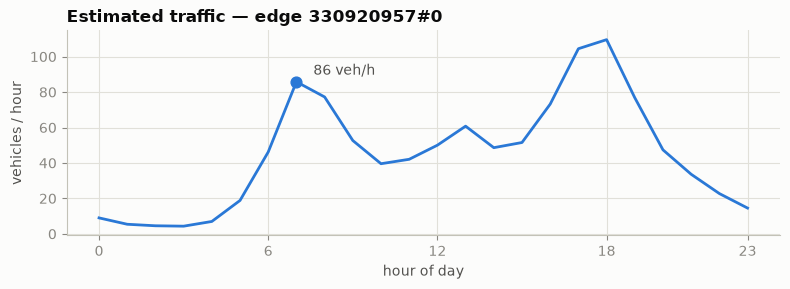

In [4]:
edge_id, hour = "330920957#0", 7

rates = predict_fn(meta["edges"].index(edge_id))[0]
print(f"{edge_id} at {hour:02d}:00  ->  {rates[hour]:.1f} vehicles/hour")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(24), rates, color=BLUE, lw=2)
ax.scatter([hour], [rates[hour]], color=BLUE, s=60, zorder=3)
ax.annotate(f"{rates[hour]:.0f} veh/h", (hour, rates[hour]),
            xytext=(hour + 0.6, rates[hour] + 4), color=INK2)
ax.set_title(f"Estimated traffic — edge {edge_id}", loc="left", fontweight="bold")
ax.set_xlabel("hour of day"), ax.set_ylabel("vehicles / hour")
ax.set_xticks([0, 6, 12, 18, 23])
plt.tight_layout()

## Simulated dataset at a glance

One row per (simulated day, edge, hour): how many vehicles entered that edge.

In [5]:
data = pd.read_csv(f"{DATA_DIR}/traffic.csv.gz")
print(f"{len(data):,} rows | {data['scenario'].nunique()} days x "
      f"{data['edge'].nunique():,} edges x 24 h | "
      f"{data['count'].sum()/data['scenario'].nunique():,.0f} vehicle-entries per day")
data.head()

4,649,760 rows | 60 days x 3,229 edges x 24 h | 211,381 vehicle-entries per day


,scenario,edge,hour,count
0,0,-1022848986#0,0,0
1,0,-1022848986#0,1,0
2,0,-1022848986#0,2,0
3,0,-1022848986#0,3,0
4,0,-1022848986#0,4,0


## Train a small model right here

A scaled-down version of `scripts/train.py`: 10 training days / 2 held-out
days, a 16-d embedding, 64-wide MLP, 6 epochs of Poisson-loss training —
a few seconds on GPU. The full run in the README just uses more days, a
bigger net, and early stopping.

epoch 0  loss -1.7282
epoch 1  loss -3.6226
epoch 2  loss -4.4079


epoch 3  loss -4.6259
epoch 4  loss -4.6753
epoch 5  loss -4.6931
held-out days: accuracy 94.41%  R2 0.947  MAE 0.86


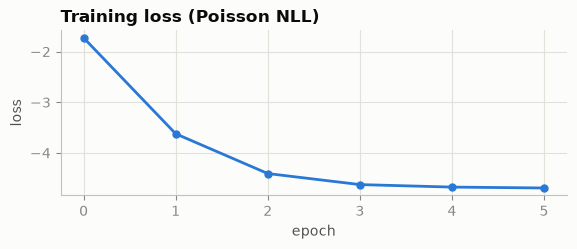

In [6]:
import torch
import torch.nn as nn
from train import MLP, metrics

device = "cuda" if torch.cuda.is_available() else "cpu"

demo = data[data["scenario"] < 12]                       # 10 train + 2 test days
edge2idx = {e: i for i, e in enumerate(meta["edges"])}
e_idx  = torch.tensor(demo["edge"].map(edge2idx).to_numpy(), device=device)
hour_t = torch.tensor(demo["hour"].to_numpy(), device=device)
y_t    = torch.tensor(demo["count"].to_numpy(np.float32), device=device)
stat_np = ((pd.read_csv(f"{DATA_DIR}/edges.csv")[meta["stat_cols"]].to_numpy(np.float32)
            - np.array(meta["stat_mean"], np.float32))
           / np.array(meta["stat_std"], np.float32))
stat_t = torch.tensor(stat_np, device=device)
tr = torch.nonzero(torch.tensor((demo["scenario"] < 10).to_numpy(), device=device)).squeeze(1)
te = torch.nonzero(torch.tensor((demo["scenario"] >= 10).to_numpy(), device=device)).squeeze(1)

small = MLP(len(meta["edges"]), len(meta["stat_cols"]), emb_dim=16, hidden=64).to(device)
opt = torch.optim.Adam(small.parameters(), lr=3e-3)

losses = []
for epoch in range(6):
    small.train()
    tot = 0.0
    for b in tr[torch.randperm(len(tr), device=device)].split(16384):
        opt.zero_grad()
        loss = nn.functional.poisson_nll_loss(
            small(e_idx[b], hour_t[b], stat_t[e_idx[b]]), y_t[b], log_input=True)
        loss.backward()
        opt.step()
        tot += loss.item() * len(b)
    losses.append(tot / len(tr))
    print(f"epoch {epoch}  loss {losses[-1]:.4f}")

small.eval()
with torch.no_grad():
    pred_te = torch.cat([torch.exp(small(e_idx[b], hour_t[b], stat_t[e_idx[b]]))
                         for b in te.split(65536)])
m = metrics(y_t[te].cpu().numpy(), pred_te.cpu().numpy(), abs_tol=3, rel_tol=0.2)
print(f"held-out days: accuracy {m['accuracy']*100:.2f}%  R2 {m['r2']:.3f}  MAE {m['mae']:.2f}")

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.plot(losses, color=BLUE, lw=2, marker="o", ms=5)
ax.set_title("Training loss (Poisson NLL)", loc="left", fontweight="bold")
ax.set_xlabel("epoch"), ax.set_ylabel("loss")
plt.tight_layout()

## Full visualization suite

The same four figures `scripts/visualize.py` produces: network heatmaps at key
hours, predicted vs simulated profiles, typical-day accuracy, and the
network-wide daily curve.

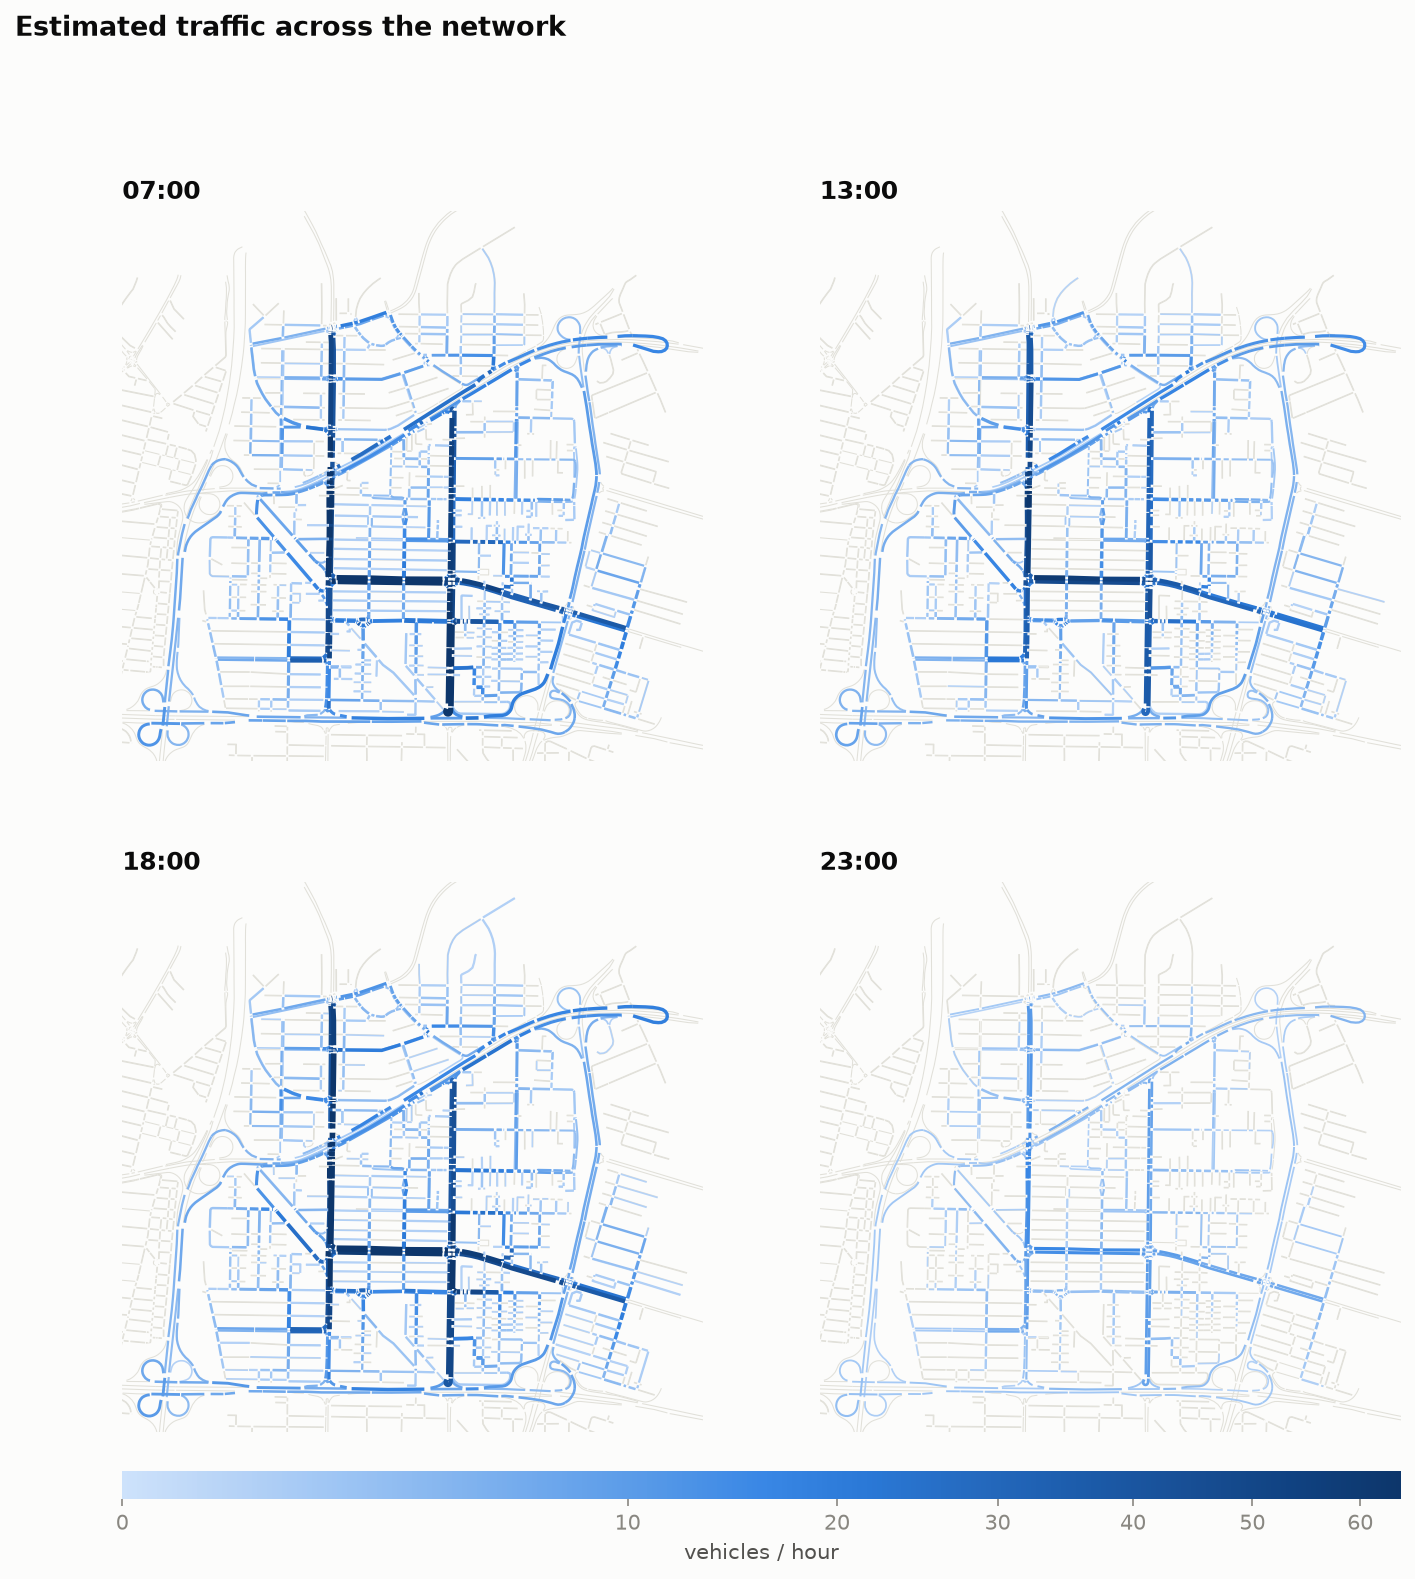

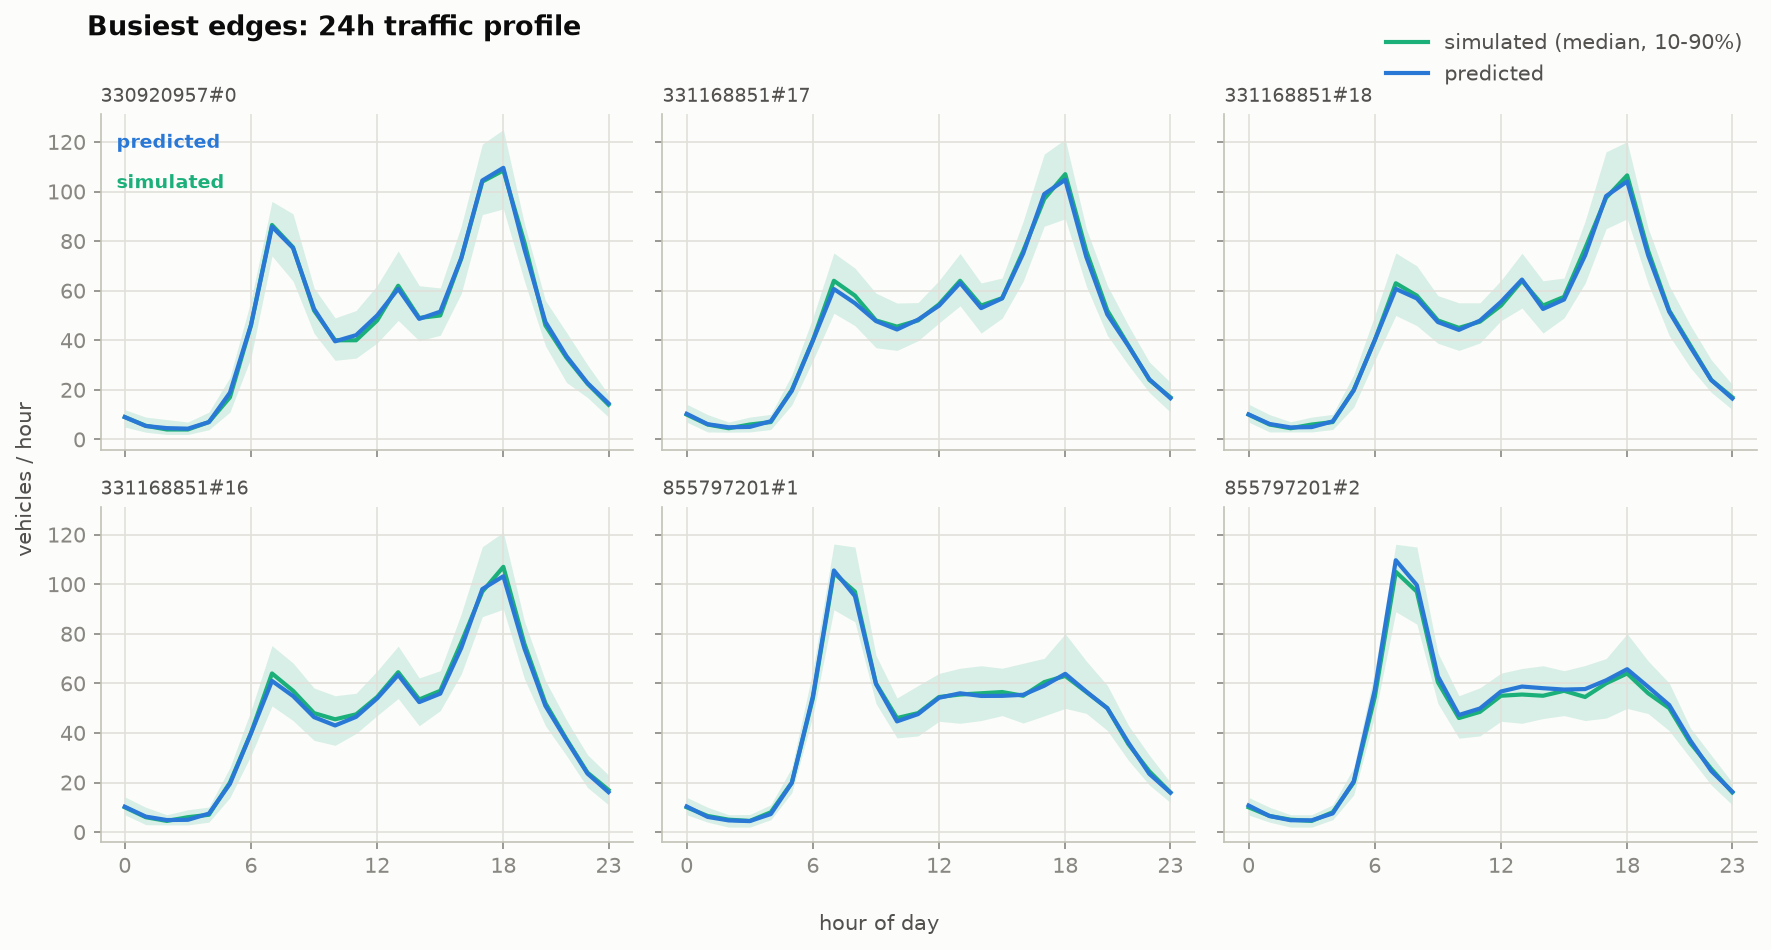

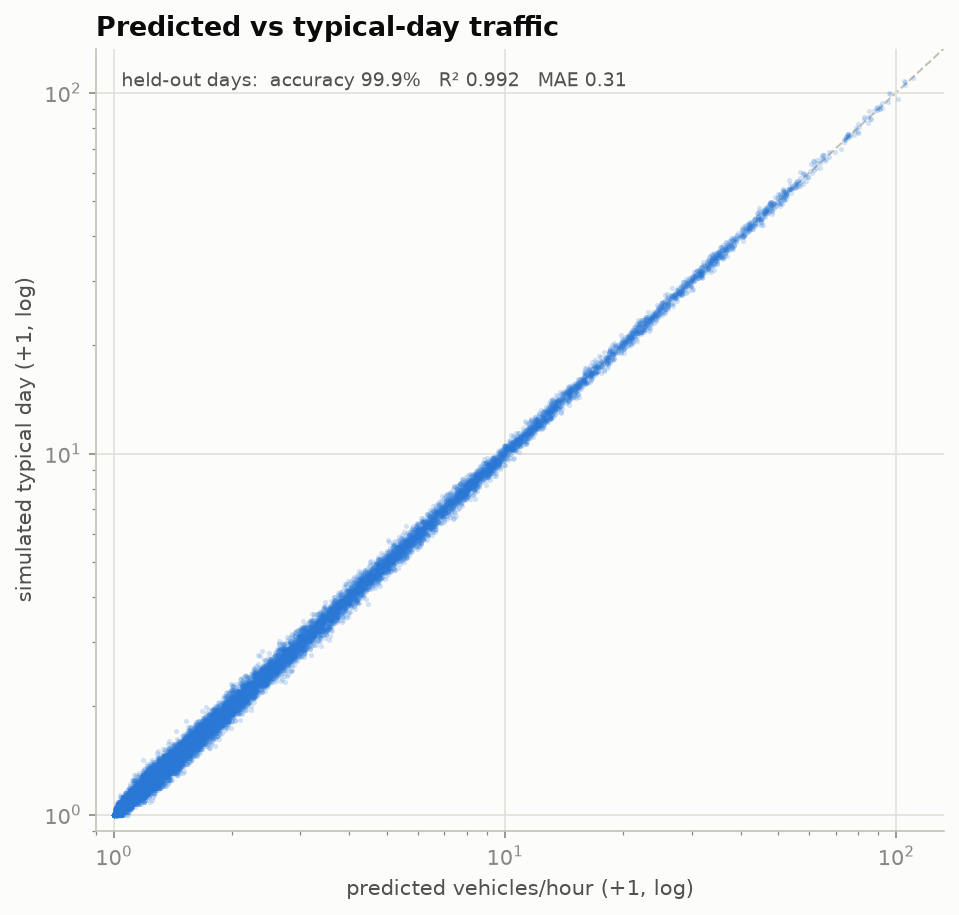

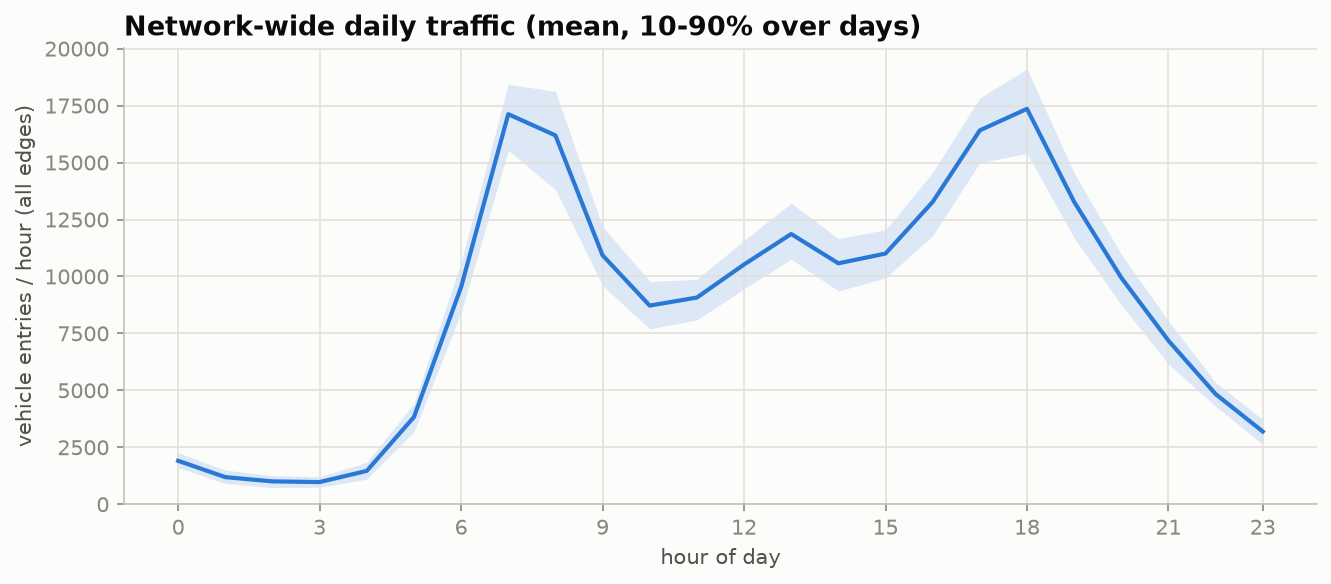

In [7]:
import os, sumolib
from IPython.display import Image, display
from visualize import fig_network, fig_profiles, fig_scatter, fig_daily

net = sumolib.net.readNet(NET_FILE)
os.makedirs("output/figures", exist_ok=True)

fig_network(net, meta, preds, [7, 13, 18, 23], "output/figures/network_traffic.png")
fig_profiles(data, meta, preds, 6,             "output/figures/edge_profiles.png")
fig_scatter(data, meta, preds,                 "output/figures/pred_vs_actual.png")
fig_daily(data,                                "output/figures/daily_profile.png")

for f in ["network_traffic", "edge_profiles", "pred_vs_actual", "daily_profile"]:
    display(Image(f"output/figures/{f}.png", width=850))